In [1]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline


import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.helpers import Flip

import optax
from optax import adam

import jax
from jax import numpy as jnp

In [2]:
input_dim = 2

In [3]:
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
target_samples1 = p.sample(jax.random.PRNGKey(0), (1000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (1000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


In [10]:

def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jax.nn.softplus(scale) + 0.1
    return loc + scale*x

def affine_bijector(params, x):
    return jax.vmap(lambda params, x: rational_quadratic_spline(params, x, range_min_x=-4, range_max_x=4,range_min_y = -8., range_max_y=8.), in_axes=(0, 0))(params,x)

bijector_dim = 15

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(1, affine_bijector, bijector_dim),Flip(), CouplingMLP(1, affine_bijector, bijector_dim), Flip(), CouplingMLP(1, affine_bijector, bijector_dim),Flip(), CouplingMLP(1, affine_bijector, bijector_dim),Flip(), CouplingMLP(1, affine_bijector, bijector_dim)])
    return nn(x)

init, apply = forward.init, forward.apply

In [11]:
params = init(jax.random.PRNGKey(0), jnp.ones((1,input_dim)))
y = apply(params, jnp.ones((1,input_dim)))

q = TransformedDistribution(p, lambda x: apply(params, x))
samples = q.sample(jax.random.PRNGKey(0), (100,))

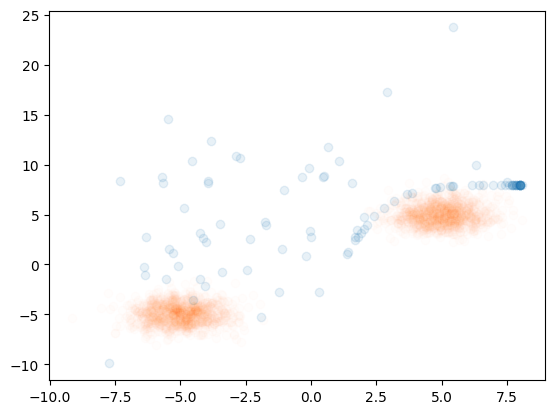

In [14]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [106]:
@jax.jit
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: apply(params, x))
    return -q.log_prob(x).mean()

In [76]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

for i in range(10000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

2362.649
4.7976594
4.508946
4.3673034
4.163006
3.9592712
3.8243887
3.7736263
3.7666438
3.761719


In [13]:
q = TransformedDistribution(p, lambda x: apply(params, x))
samples = q.sample(jax.random.PRNGKey(0), sample_shape=(1000,))

(-10.0, 10.0)

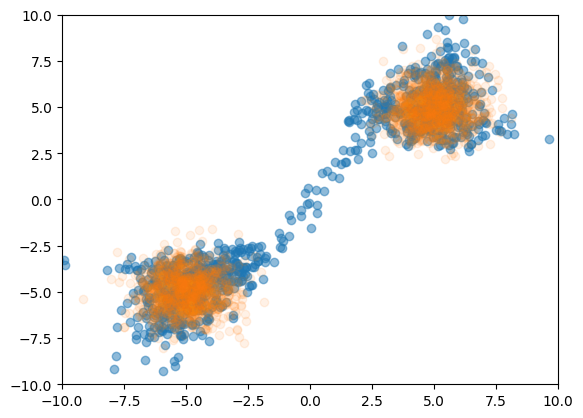

In [14]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

plt.xlim(-10, 10)
plt.ylim(-10, 10)

In [77]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.helpers import Flip
import optax
from optax import adam

import jax
from jax import numpy as jnp

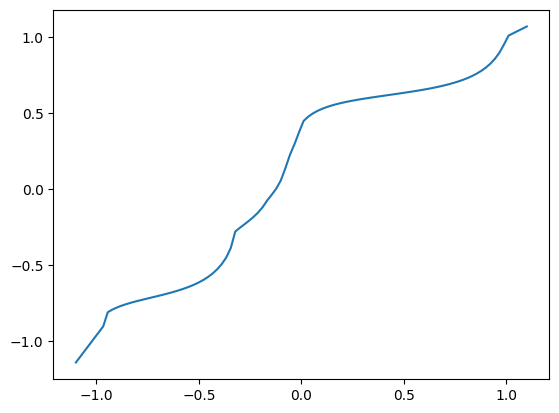

In [78]:
from probjax.nn.bijective import rational_quadratic_spline, _rational_quadratic_spline_fwd, custom_inverse
import matplotlib.pyplot as plt

params = jnp.concatenate([2*jax.random.normal(jax.random.PRNGKey(0), (20,)), jax.random.normal(jax.random.PRNGKey(0), (20,)) , jax.random.normal(jax.random.PRNGKey(0), (20,))])
x = jnp.linspace(-1.1, 1.1, 100)
y = jax.vmap(rational_quadratic_spline, in_axes=(None,0))(params,x)
x = jax.vmap(rational_quadratic_spline.inv, in_axes=(None,0))(params,y)

plt.plot(x,y)

In [87]:
def f(x):
    return jax.vmap(rational_quadratic_spline, in_axes=(None, 0))(params, x)


In [88]:
inverse_and_logabsdet(f)(jnp.ones((10,)))

(Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32),
 Array([-1.136, -1.136, -1.136, -1.136, -1.136, -1.136, -1.136, -1.136,
        -1.136, -1.136], dtype=float32))

In [8]:
jaxpr_closed = jax.make_jaxpr(f)(2.)
inverese_jaxpr = jaxpr_closed.eqns[0].params['forward_jaxpr']

In [23]:
jaxpr_closed.jaxpr.constvars[0].aval

ShapedArray(float32[60])

In [24]:
jax.core.eval_jaxpr(jaxpr_closed.jaxpr, jaxpr_closed.consts,2.)

[Array(1.673, dtype=float32)]

In [9]:
inverese_jaxpr.jaxpr.constvars[0].aval

ShapedArray(int32[1])

In [10]:
inverese_jaxpr.jaxpr.invars[0].aval

ShapedArray(float32[60])

In [25]:
jax.core.eval_jaxpr(inverese_jaxpr.jaxpr,inverese_jaxpr.consts ,params, 2.)

[Array(1.673, dtype=float32)]

In [36]:
contsvars

[a]

In [30]:
outvars

[c]

In [9]:

def g(y, x):
    return x + y

g = custom_inverse(g)

g.definv(lambda y,x: x - y)

jax.vmap(g)(jnp.ones(10), jnp.ones(10))

Array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.], dtype=float32)

In [20]:
y = rational_quadratic_spline(params, 3.)
y


Array(2.346, dtype=float32)

In [21]:
rational_quadratic_spline.inv(params, y)

Array(3., dtype=float32)

In [ ]:
from probjax.core.custom_primitives.custom_inverse import custom_inverse

rqs = custom_inverse(rational_quadratic_spline, static_argnums=(0,))
rqs.definv(rational_quadratic_spline)

<function probjax.core.custom_primitives.custom_inverse.custom_inverse.definv.<locals>.wrapped_inv(*args)>

In [ ]:
rqs.inv(params, 2.)

Array(1.673, dtype=float32)

In [ ]:
start_and_bin_widhts = jnp.linspace(-5, 10, 9)

jnp.cumsum(jax.nn.softplus(start_and_bin_widhts)) + start_and_bin_widhts[0]

Array([-4.993, -4.95 , -4.698, -3.645, -1.066,  3.322,  9.574, 17.699,
       27.699], dtype=float32)

In [20]:
jnp.cumsum(params[:10])

Array([ -9., -18., -27., -36., -45., -54., -63., -72., -81., -90.],      dtype=float32)